<a href="https://colab.research.google.com/github/khoirul2003/PVCK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D-1 PERCOBAAN HISTOGRAM**

1. o to https://colab.research.google.com/ . After making sure that Google Colab is connected to your Github , continue by selecting the repository that was used in the lab last week, rename the file to "Week 6 .ipynb"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import the following libraries that will be used during the following week 6 practicum trial.

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3. Make an image histogram like the following histogram output based on the flowchart below (Use image lena.jpg)

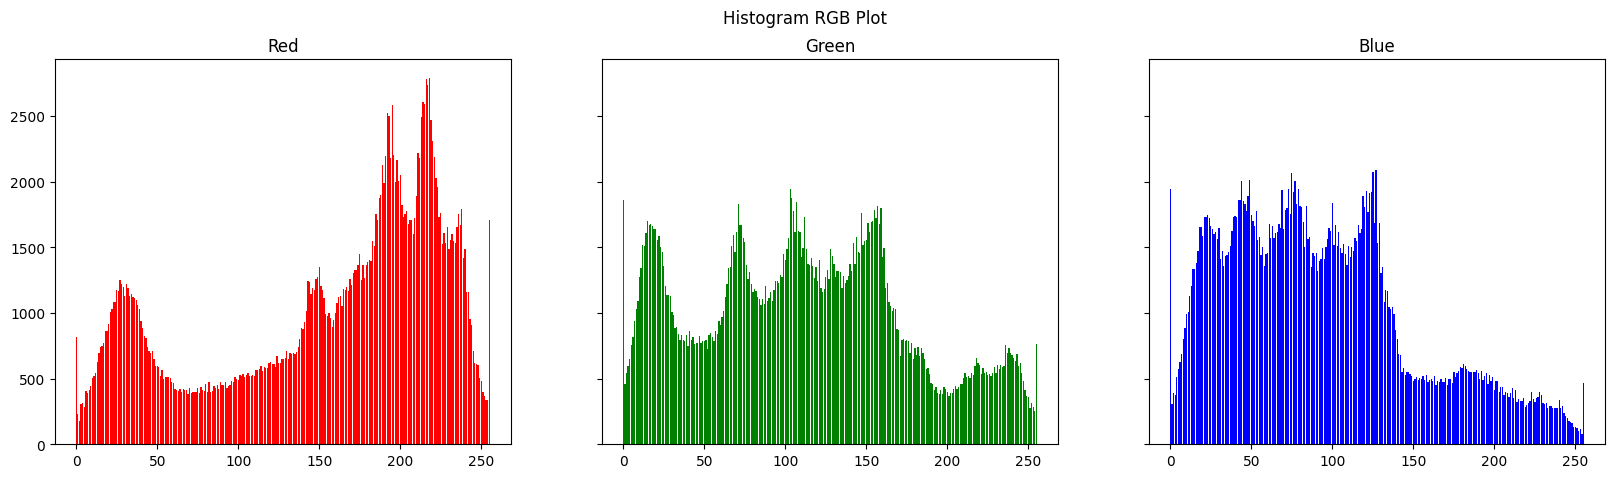

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/Images/lena.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

height, width, _ = img.shape
red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(height):
    for x in range(width):
        r, g, b = img[y][x]
        red[r] += 1
        green[g] += 1
        blue[b] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Histogram RGB Plot")

axs[0].set_title('Red')
axs[0].bar(names, red, color='red')

axs[1].set_title('Green')
axs[1].bar(names, green, color='green')

axs[2].set_title('Blue')
axs[2].bar(names, blue, color='blue')

plt.show()

4. After working on question no. 3, make the same image histogram but use the library that is owned by NumPy, namely " histogram ". Compare the results. Does the output appear the same?

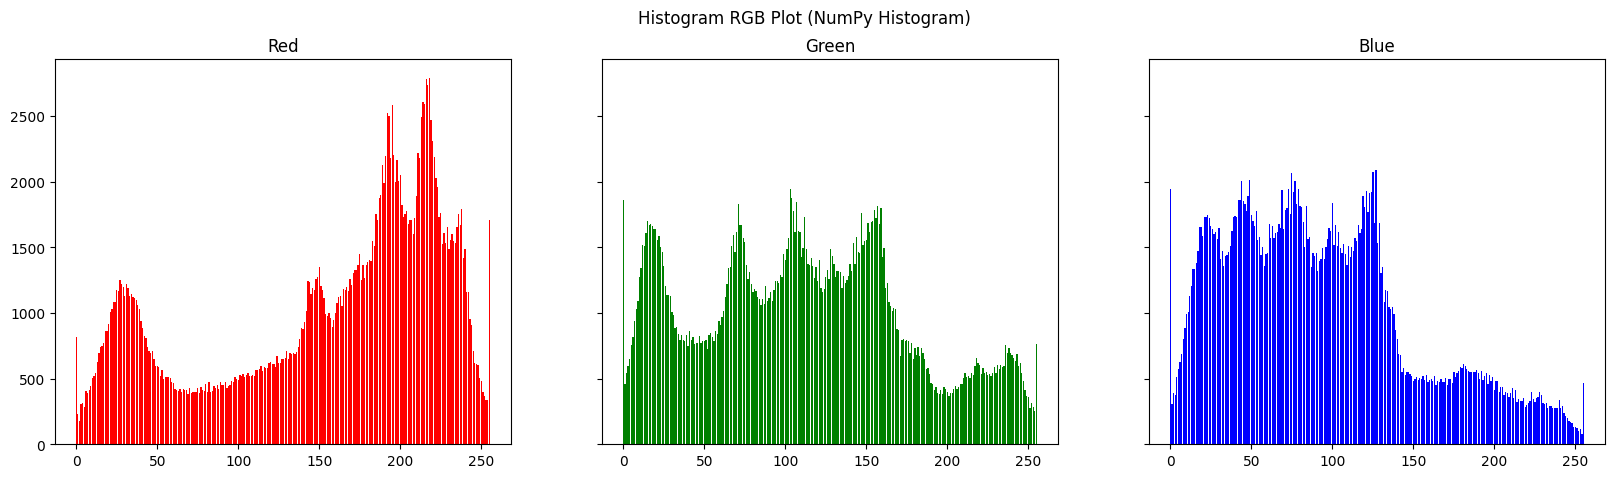

In [5]:
img = cv2.imread('/content/drive/MyDrive/Images/lena.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

r_channel = img[:,:,0].ravel()
g_channel = img[:,:,1].ravel()
b_channel = img[:,:,2].ravel()

hist_r, bins_r = np.histogram(r_channel, bins=256, range=(0,256))
hist_g, bins_g = np.histogram(g_channel, bins=256, range=(0,256))
hist_b, bins_b = np.histogram(b_channel, bins=256, range=(0,256))

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Histogram RGB Plot (NumPy Histogram)")

axs[0].set_title('Red')
axs[0].bar(names, hist_r, color='red')

axs[1].set_title('Green')
axs[1].bar(names, hist_g, color='green')

axs[2].set_title('Blue')
axs[2].bar(names, hist_b, color='blue')

plt.show()

5. Make an image histogram such as the output equalization histogram and also the image display before and after the following equalization histogram process based on the flowchart below : (Use image lena_lc .jpg)

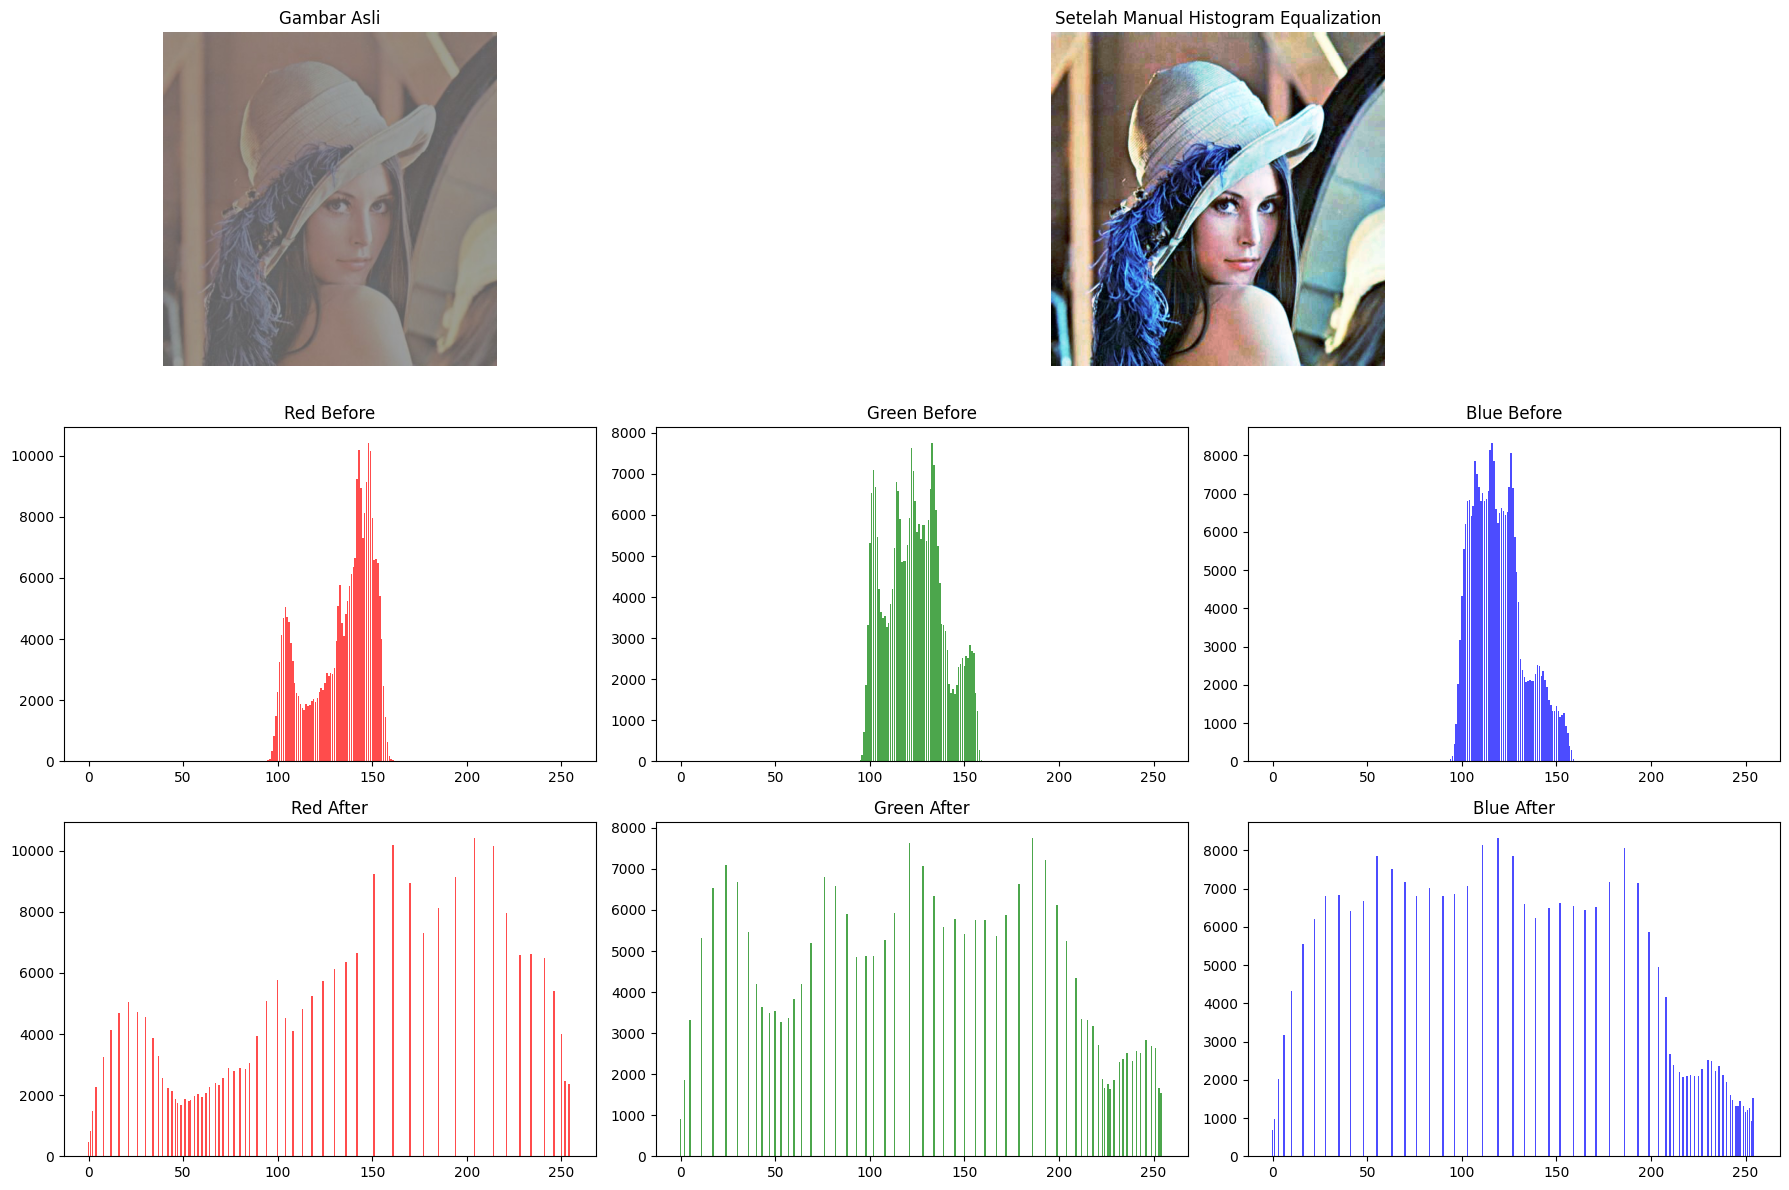

Verifikasi: Bandingkan hasil manual vs OpenCV
Rata-rata perbedaan pixel: 0.5213


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

image = cv2.imread('/content/drive/MyDrive/Images/lena_lc.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def manual_histogram_equalization(channel):
    """
    Implementasi manual histogram equalization
    """
    hist, _ = np.histogram(channel.flatten(), bins=256, range=(0, 256))

    cdf = hist.cumsum()

    cdf_normalized = ((cdf - cdf.min()) / (cdf.max() - cdf.min())) * 255
    cdf_normalized = cdf_normalized.astype(np.uint8)

    equalized_channel = cdf_normalized[channel]

    return equalized_channel

channels = cv2.split(image)

eq_channels = []
for ch in channels:
    eq_ch = manual_histogram_equalization(ch)
    eq_channels.append(eq_ch)

equalized_image = cv2.merge(eq_channels)

def compute_hist(img):
    """
    Fungsi untuk menghitung histogram manual
    """
    height, width, _ = img.shape
    red = [0] * 256
    green = [0] * 256
    blue = [0] * 256

    for y in range(height):
        for x in range(width):
            r, g, b = img[y][x]
            red[r] += 1
            green[g] += 1
            blue[b] += 1
    return red, green, blue

red_before, green_before, blue_before = compute_hist(image)
red_after, green_after, blue_after = compute_hist(equalized_image)

names = np.arange(256)
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, :3//2])
ax1.imshow(image)
ax1.set_title("Gambar Asli")
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 3//2:])
ax2.imshow(equalized_image)
ax2.set_title("Setelah Manual Histogram Equalization")
ax2.axis('off')

ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(names, red_before, color='red', alpha=0.7)
ax3.set_title("Red Before")

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(names, green_before, color='green', alpha=0.7)
ax4.set_title("Green Before")

ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(names, blue_before, color='blue', alpha=0.7)
ax5.set_title("Blue Before")

ax6 = fig.add_subplot(gs[2, 0])
ax6.bar(names, red_after, color='red', alpha=0.7)
ax6.set_title("Red After")

ax7 = fig.add_subplot(gs[2, 1])
ax7.bar(names, green_after, color='green', alpha=0.7)
ax7.set_title("Green After")

ax8 = fig.add_subplot(gs[2, 2])
ax8.bar(names, blue_after, color='blue', alpha=0.7)
ax8.set_title("Blue After")

plt.tight_layout()
plt.show()

print("Verifikasi: Bandingkan hasil manual vs OpenCV")
channels_cv2 = cv2.split(image)
eq_channels_cv2 = [cv2.equalizeHist(ch) for ch in channels_cv2]
equalized_image_cv2 = cv2.merge(eq_channels_cv2)

difference = np.mean(np.abs(equalized_image.astype(float) - equalized_image_cv2.astype(float)))
print(f"Rata-rata perbedaan pixel: {difference:.4f}")

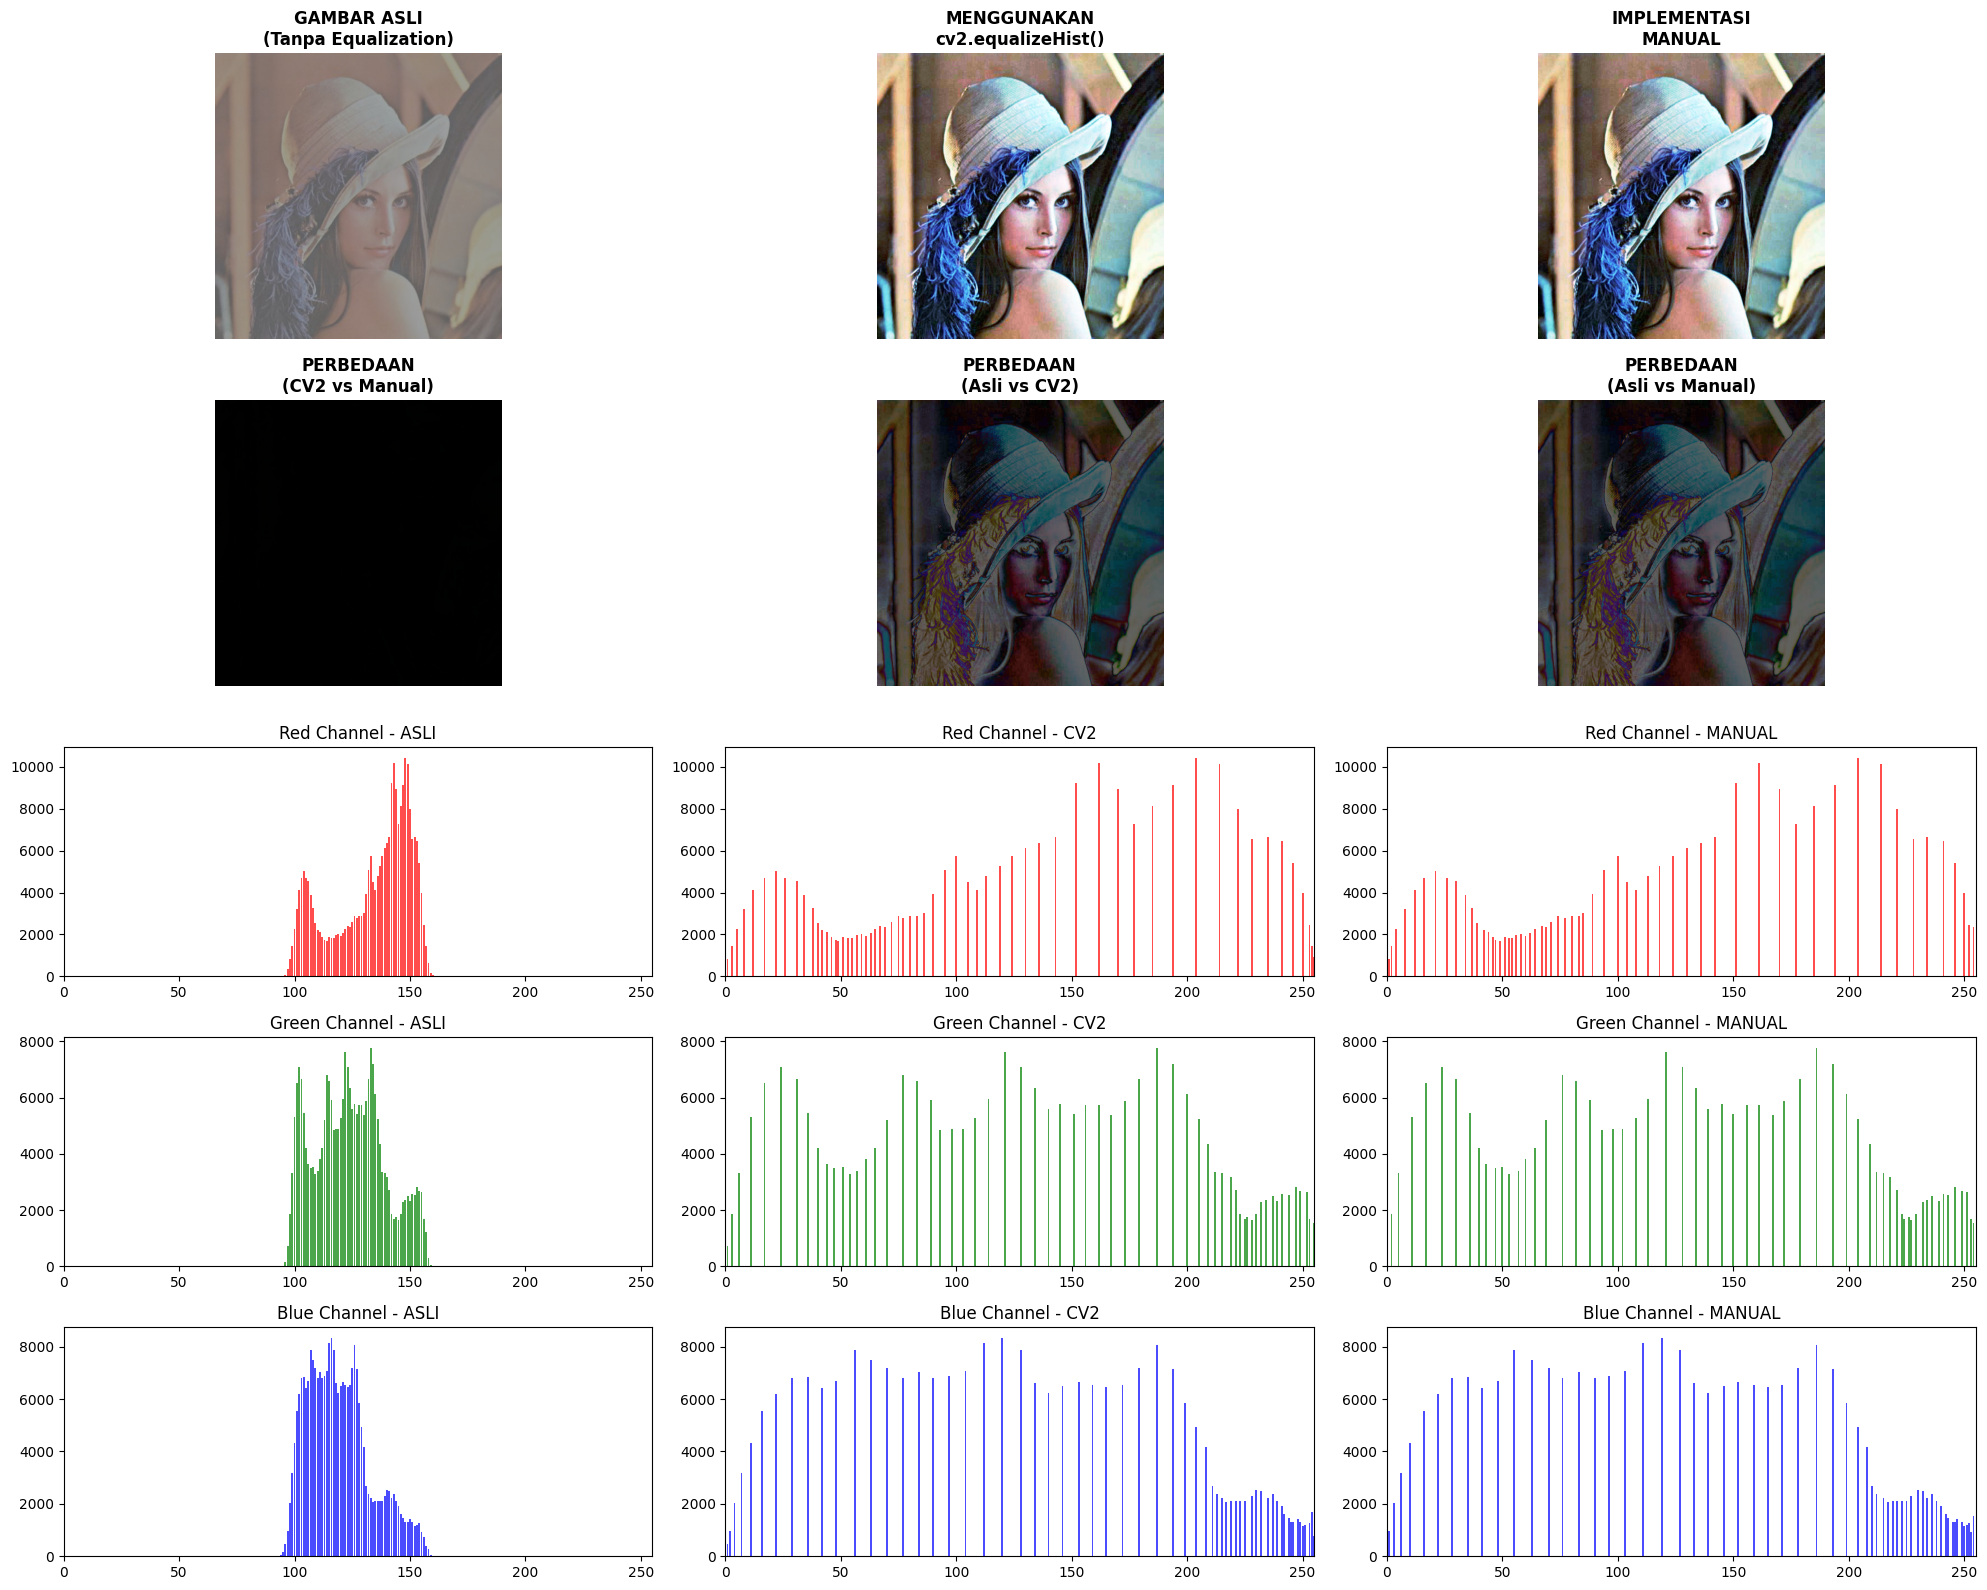

ANALISIS PERBANDINGAN HASIL
Perbedaan CV2 vs Manual:
  - Rata-rata perbedaan pixel: 0.521338
  - Maksimum perbedaan pixel: 1.000000

Perbedaan Asli vs Hasil Equalization:
  - Asli vs CV2: 51.98
  - Asli vs Manual: 52.00

Apakah hasil CV2 dan Manual identik? False

Statistik Gambar:
Original - Mean: 125.66, Std: 16.38
CV2      - Mean: 130.21, Std: 73.59
Manual   - Mean: 129.69, Std: 73.65


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

image = cv2.imread('/content/drive/MyDrive/Images/lena_lc.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def manual_histogram_equalization(channel):
    """
    Implementasi manual histogram equalization
    """
    hist, _ = np.histogram(channel.flatten(), bins=256, range=(0, 256))

    cdf = hist.cumsum()

    cdf_normalized = ((cdf - cdf.min()) / (cdf.max() - cdf.min())) * 255
    cdf_normalized = cdf_normalized.astype(np.uint8)

    equalized_channel = cdf_normalized[channel]

    return equalized_channel

original_image = image.copy()

channels_cv2 = cv2.split(image)
eq_channels_cv2 = [cv2.equalizeHist(ch) for ch in channels_cv2]
equalized_image_cv2 = cv2.merge(eq_channels_cv2)

channels_manual = cv2.split(image)
eq_channels_manual = []
for ch in channels_manual:
    eq_ch = manual_histogram_equalization(ch)
    eq_channels_manual.append(eq_ch)
equalized_image_manual = cv2.merge(eq_channels_manual)

def compute_hist(img):
    """
    Fungsi untuk menghitung histogram manual
    """
    height, width, _ = img.shape
    red = [0] * 256
    green = [0] * 256
    blue = [0] * 256

    for y in range(height):
        for x in range(width):
            r, g, b = img[y][x]
            red[r] += 1
            green[g] += 1
            blue[b] += 1
    return red, green, blue

red_orig, green_orig, blue_orig = compute_hist(original_image)
red_cv2, green_cv2, blue_cv2 = compute_hist(equalized_image_cv2)
red_manual, green_manual, blue_manual = compute_hist(equalized_image_manual)

names = np.arange(256)
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(5, 3, figure=fig, height_ratios=[1, 1, 0.8, 0.8, 0.8])

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(original_image)
ax1.set_title("GAMBAR ASLI\n(Tanpa Equalization)", fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(equalized_image_cv2)
ax2.set_title("MENGGUNAKAN\ncv2.equalizeHist()", fontsize=12, fontweight='bold')
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(equalized_image_manual)
ax3.set_title("IMPLEMENTASI\nMANUAL", fontsize=12, fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[1, 0])
difference_cv2_manual = np.abs(equalized_image_cv2.astype(float) - equalized_image_manual.astype(float))
ax4.imshow(difference_cv2_manual.astype(np.uint8))
ax4.set_title("PERBEDAAN\n(CV2 vs Manual)", fontsize=12, fontweight='bold')
ax4.axis('off')

ax5 = fig.add_subplot(gs[1, 1])
difference_orig_cv2 = np.abs(original_image.astype(float) - equalized_image_cv2.astype(float))
ax5.imshow(difference_orig_cv2.astype(np.uint8))
ax5.set_title("PERBEDAAN\n(Asli vs CV2)", fontsize=12, fontweight='bold')
ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 2])
difference_orig_manual = np.abs(original_image.astype(float) - equalized_image_manual.astype(float))
ax6.imshow(difference_orig_manual.astype(np.uint8))
ax6.set_title("PERBEDAAN\n(Asli vs Manual)", fontsize=12, fontweight='bold')
ax6.axis('off')

ax7 = fig.add_subplot(gs[2, 0])
ax7.bar(names, red_orig, color='red', alpha=0.7, label='Original')
ax7.set_title("Red Channel - ASLI")
ax7.set_xlim(0, 255)

ax8 = fig.add_subplot(gs[2, 1])
ax8.bar(names, red_cv2, color='red', alpha=0.7, label='CV2')
ax8.set_title("Red Channel - CV2")
ax8.set_xlim(0, 255)

ax9 = fig.add_subplot(gs[2, 2])
ax9.bar(names, red_manual, color='red', alpha=0.7, label='Manual')
ax9.set_title("Red Channel - MANUAL")
ax9.set_xlim(0, 255)

ax10 = fig.add_subplot(gs[3, 0])
ax10.bar(names, green_orig, color='green', alpha=0.7, label='Original')
ax10.set_title("Green Channel - ASLI")
ax10.set_xlim(0, 255)

ax11 = fig.add_subplot(gs[3, 1])
ax11.bar(names, green_cv2, color='green', alpha=0.7, label='CV2')
ax11.set_title("Green Channel - CV2")
ax11.set_xlim(0, 255)

ax12 = fig.add_subplot(gs[3, 2])
ax12.bar(names, green_manual, color='green', alpha=0.7, label='Manual')
ax12.set_title("Green Channel - MANUAL")
ax12.set_xlim(0, 255)

ax13 = fig.add_subplot(gs[4, 0])
ax13.bar(names, blue_orig, color='blue', alpha=0.7, label='Original')
ax13.set_title("Blue Channel - ASLI")
ax13.set_xlim(0, 255)

ax14 = fig.add_subplot(gs[4, 1])
ax14.bar(names, blue_cv2, color='blue', alpha=0.7, label='CV2')
ax14.set_title("Blue Channel - CV2")
ax14.set_xlim(0, 255)

ax15 = fig.add_subplot(gs[4, 2])
ax15.bar(names, blue_manual, color='blue', alpha=0.7, label='Manual')
ax15.set_title("Blue Channel - MANUAL")
ax15.set_xlim(0, 255)

plt.tight_layout()
plt.show()

print("="*60)
print("ANALISIS PERBANDINGAN HASIL")
print("="*60)

diff_cv2_manual = np.mean(np.abs(equalized_image_cv2.astype(float) - equalized_image_manual.astype(float)))
max_diff_cv2_manual = np.max(np.abs(equalized_image_cv2.astype(float) - equalized_image_manual.astype(float)))

print(f"Perbedaan CV2 vs Manual:")
print(f"  - Rata-rata perbedaan pixel: {diff_cv2_manual:.6f}")
print(f"  - Maksimum perbedaan pixel: {max_diff_cv2_manual:.6f}")

diff_orig_cv2 = np.mean(np.abs(original_image.astype(float) - equalized_image_cv2.astype(float)))
diff_orig_manual = np.mean(np.abs(original_image.astype(float) - equalized_image_manual.astype(float)))

print(f"\nPerbedaan Asli vs Hasil Equalization:")
print(f"  - Asli vs CV2: {diff_orig_cv2:.2f}")
print(f"  - Asli vs Manual: {diff_orig_manual:.2f}")

is_identical = np.array_equal(equalized_image_cv2, equalized_image_manual)
print(f"\nApakah hasil CV2 dan Manual identik? {is_identical}")

print(f"\nStatistik Gambar:")
print(f"Original - Mean: {np.mean(original_image):.2f}, Std: {np.std(original_image):.2f}")
print(f"CV2      - Mean: {np.mean(equalized_image_cv2):.2f}, Std: {np.std(equalized_image_cv2):.2f}")
print(f"Manual   - Mean: {np.mean(equalized_image_manual):.2f}, Std: {np.std(equalized_image_manual):.2f}")

7. Do the mapping process of 16 million RGB colors into just 8 colors, namely black, green, yellow, blue, cyan, magenta, white as shown in the following output based on the flowchart below! (Use the image testlena .jpg)


GAMBAR ASLI:
Jumlah warna unik: 22382

GAMBAR SETELAH PEMETAAN 8 WARNA:
Jumlah warna unik: 8
Warna-warna unik (R, G, B):
  (np.uint8(0), np.uint8(0), np.uint8(0)) -> Hitam
  (np.uint8(0), np.uint8(0), np.uint8(255)) -> Biru
  (np.uint8(0), np.uint8(255), np.uint8(0)) -> Hijau
  (np.uint8(0), np.uint8(255), np.uint8(255)) -> Cyan
  (np.uint8(255), np.uint8(0), np.uint8(0)) -> Merah
  (np.uint8(255), np.uint8(0), np.uint8(255)) -> Magenta
  (np.uint8(255), np.uint8(255), np.uint8(0)) -> Kuning
  (np.uint8(255), np.uint8(255), np.uint8(255)) -> Putih


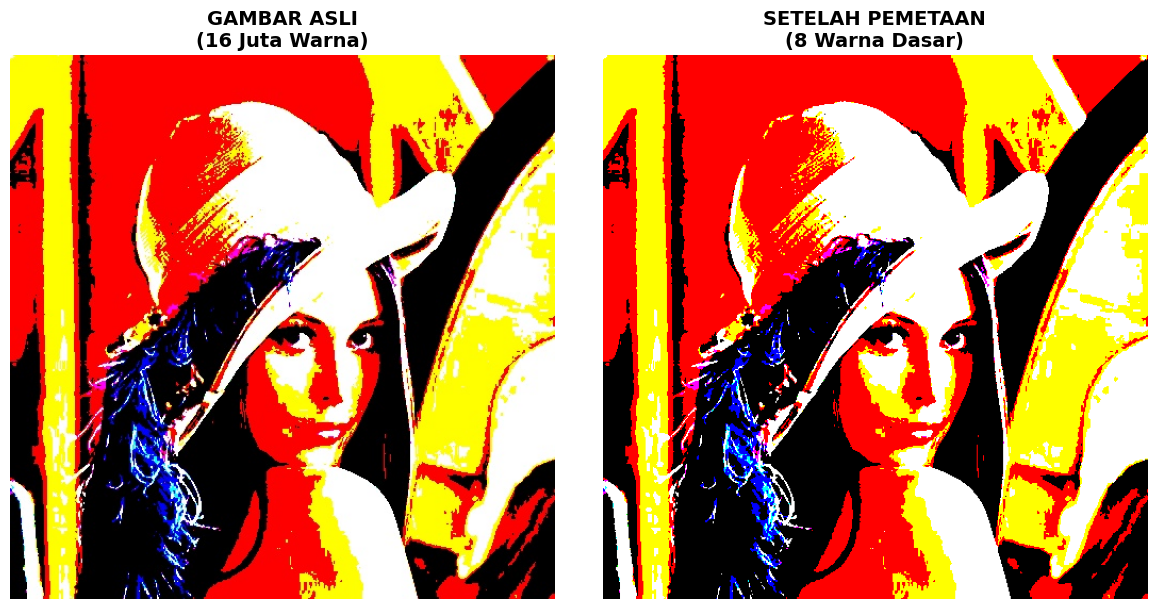


STATISTIK HASIL PEMETAAN
Ukuran gambar: (512, 512, 3)
Total pixel: 262,144

Distribusi warna dalam hasil pemetaan:
  Hitam    (np.uint8(0), np.uint8(0), np.uint8(0)): 75,880 pixel (28.95%)
  Biru     (np.uint8(0), np.uint8(0), np.uint8(255)):  2,958 pixel ( 1.13%)
  Hijau    (np.uint8(0), np.uint8(255), np.uint8(0)):      7 pixel ( 0.00%)
  Cyan     (np.uint8(0), np.uint8(255), np.uint8(255)):    468 pixel ( 0.18%)
  Merah    (np.uint8(255), np.uint8(0), np.uint8(0)): 75,544 pixel (28.82%)
  Magenta  (np.uint8(255), np.uint8(0), np.uint8(255)):    649 pixel ( 0.25%)
  Kuning   (np.uint8(255), np.uint8(255), np.uint8(0)): 47,734 pixel (18.21%)
  Putih    (np.uint8(255), np.uint8(255), np.uint8(255)): 58,904 pixel (22.47%)


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

image = cv2.imread('/content/drive/MyDrive/Images/testlena.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def rgb_to_8_colors(image):
    """
    Fungsi untuk memetakan 16 juta warna RGB ke 8 warna dasar
    berdasarkan diagram alir:
    - Hitam (0,0,0)
    - Merah (255,0,0)
    - Hijau (0,255,0)
    - Kuning (255,255,0)
    - Biru (0,0,255)
    - Cyan (0,255,255)
    - Magenta (255,0,255)
    - Putih (255,255,255)
    """

    result_image = np.zeros_like(image)
    height, width, channels = image.shape

    threshold = 128

    for y in range(height):
        for x in range(width):
            r, g, b = image[y, x]

            r_bin = 1 if r >= threshold else 0
            g_bin = 1 if g >= threshold else 0
            b_bin = 1 if b >= threshold else 0

            if r_bin == 0 and g_bin == 0 and b_bin == 0:
                result_image[y, x] = [0, 0, 0]
            elif r_bin == 0 and g_bin == 0 and b_bin == 1:
                result_image[y, x] = [0, 0, 255]
            elif r_bin == 0 and g_bin == 1 and b_bin == 0:
                result_image[y, x] = [0, 255, 0]
            elif r_bin == 0 and g_bin == 1 and b_bin == 1:
                result_image[y, x] = [0, 255, 255]
            elif r_bin == 1 and g_bin == 0 and b_bin == 0:
                result_image[y, x] = [255, 0, 0]
            elif r_bin == 1 and g_bin == 0 and b_bin == 1:
                result_image[y, x] = [255, 0, 255]
            elif r_bin == 1 and g_bin == 1 and b_bin == 0:
                result_image[y, x] = [255, 255, 0]
            elif r_bin == 1 and g_bin == 1 and b_bin == 1:
                result_image[y, x] = [255, 255, 255]

    return result_image

def rgb_to_8_colors_vectorized(image):
    """
    Versi yang lebih efisien menggunakan operasi vektor NumPy
    """
    threshold = 128

    binary_image = (image >= threshold).astype(np.uint8)

    result_image = binary_image * 255

    return result_image

mapped_image = rgb_to_8_colors(image)


def analyze_colors(image, title):
    """
    Analisis warna unik dalam gambar
    """
    pixels = image.reshape(-1, 3)

    unique_colors = np.unique(pixels, axis=0)

    print(f"\n{title}:")
    print(f"Jumlah warna unik: {len(unique_colors)}")

    if len(unique_colors) <= 20:
        print("Warna-warna unik (R, G, B):")
        color_names = {
            (0, 0, 0): "Hitam",
            (255, 0, 0): "Merah",
            (0, 255, 0): "Hijau",
            (255, 255, 0): "Kuning",
            (0, 0, 255): "Biru",
            (0, 255, 255): "Cyan",
            (255, 0, 255): "Magenta",
            (255, 255, 255): "Putih"
        }

        for color in unique_colors:
            color_tuple = tuple(color)
            name = color_names.get(color_tuple, "Tidak dikenal")
            print(f"  {color_tuple} -> {name}")

analyze_colors(image, "GAMBAR ASLI")
analyze_colors(mapped_image, "GAMBAR SETELAH PEMETAAN 8 WARNA")

def create_color_palette():

    colors = np.array([
        [0, 0, 0],        # Hitam
        [255, 0, 0],      # Merah
        [0, 255, 0],      # Hijau
        [255, 255, 0],    # Kuning
        [0, 0, 255],      # Biru
        [0, 255, 255],    # Cyan
        [255, 0, 255],    # Magenta
        [255, 255, 255]   # Putih
    ])

    # Buat palette visual
    palette = np.zeros((100, 800, 3), dtype=np.uint8)
    width_per_color = 800 // 8

    for i, color in enumerate(colors):
        start_x = i * width_per_color
        end_x = start_x + width_per_color
        palette[:, start_x:end_x] = color

    return palette, colors

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(image)
ax1.set_title("GAMBAR ASLI\n(16 Juta Warna)", fontsize=14, fontweight='bold')
ax1.axis('off')

ax2.imshow(mapped_image)
ax2.set_title("SETELAH PEMETAAN\n(8 Warna Dasar)", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("STATISTIK HASIL PEMETAAN")
print(f"{'='*60}")
print(f"Ukuran gambar: {image.shape}")
print(f"Total pixel: {image.shape[0] * image.shape[1]:,}")

pixels_mapped = mapped_image.reshape(-1, 3)
unique_mapped, counts = np.unique(pixels_mapped, axis=0, return_counts=True)

print(f"\nDistribusi warna dalam hasil pemetaan:")
color_names_dict = {
    (0, 0, 0): "Hitam",
    (255, 0, 0): "Merah",
    (0, 255, 0): "Hijau",
    (255, 255, 0): "Kuning",
    (0, 0, 255): "Biru",
    (0, 255, 255): "Cyan",
    (255, 0, 255): "Magenta",
    (255, 255, 255): "Putih"
}

for color, count in zip(unique_mapped, counts):
    color_tuple = tuple(color)
    name = color_names_dict.get(color_tuple, "Tidak dikenal")
    percentage = (count / (image.shape[0] * image.shape[1])) * 100
    print(f"  {name:8} {color_tuple}: {count:6,} pixel ({percentage:5.2f}%)")

8. Do the Floyd and Steinberg dithering process like the following output (initial image display, and after dithering display) based on the flowchart below! (Use wiki.jpg image)

Memproses gambar 534x800 dengan jarak pixel = 1


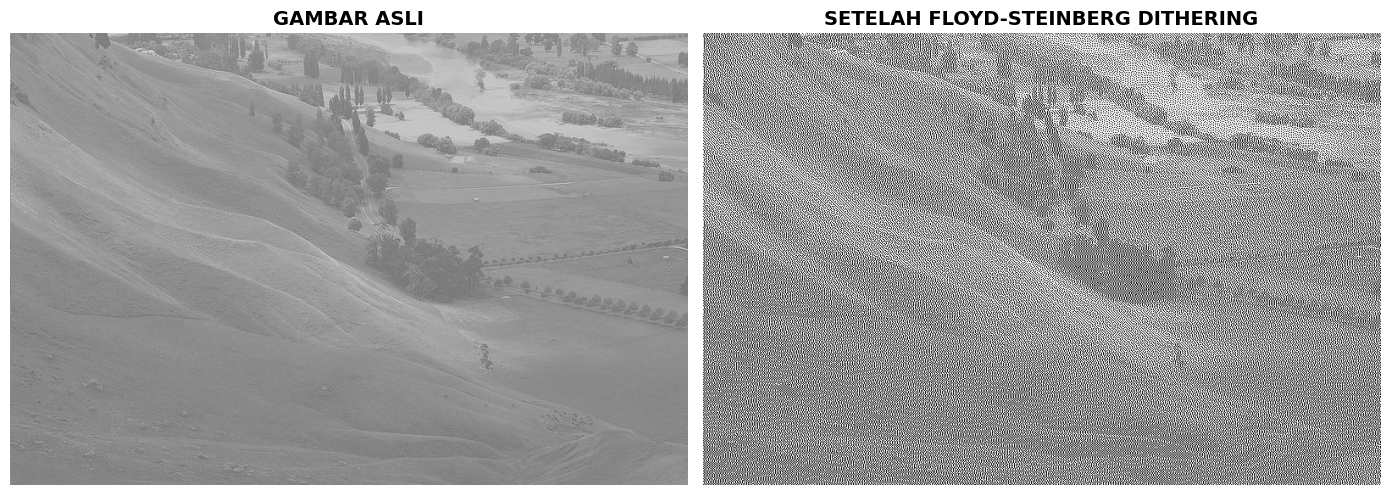


ANALISIS HASIL FLOYD-STEINBERG DITHERING
Ukuran gambar: (534, 800, 3)
Total pixel: 427,200

Statistik warna:
Gambar asli:
  - Mean: 148.01
  - Std: 15.15
  - Min: 86
  - Max: 246
Setelah dithering:
  - Mean: 148.02
  - Std: 125.84
  - Min: 0
  - Max: 255


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/content/drive/MyDrive/Images/wiki.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def threshold(nilai):
    if nilai > 255:
        return 255
    elif nilai < 0:
        return 0
    else:
        return nilai

def floyd_steinberg_dithering(image, jarak_pixel=1):
    result_image = image.astype(np.float64)
    height, width, channels = result_image.shape

    img_red = result_image[:, :, 0].copy()
    img_green = result_image[:, :, 1].copy()
    img_blue = result_image[:, :, 2].copy()

    print(f"Memproses gambar {height}x{width} dengan jarak pixel = {jarak_pixel}")

    for y in range(height):
        for x in range(width):

            pixel_red_old = img_red[y, x]
            pixel_green_old = img_green[y, x]
            pixel_blue_old = img_blue[y, x]

            pixel_red_new = np.round(jarak_pixel * pixel_red_old / 255.0) * (255 / jarak_pixel)
            pixel_green_new = np.round(jarak_pixel * pixel_green_old / 255.0) * (255 / jarak_pixel)
            pixel_blue_new = np.round(jarak_pixel * pixel_blue_old / 255.0) * (255 / jarak_pixel)

            img_red[y, x] = pixel_red_new
            img_green[y, x] = pixel_green_new
            img_blue[y, x] = pixel_blue_new

            error_red = pixel_red_old - pixel_red_new
            error_green = pixel_green_old - pixel_green_new
            error_blue = pixel_blue_old - pixel_blue_new

            if x + 1 < width:
                img_red[y, x + 1] = threshold(img_red[y, x + 1] + error_red * 7/16)
                img_green[y, x + 1] = threshold(img_green[y, x + 1] + error_green * 7/16)
                img_blue[y, x + 1] = threshold(img_blue[y, x + 1] + error_blue * 7/16)

            if y + 1 < height and x - 1 >= 0:
                img_red[y + 1, x - 1] = threshold(img_red[y + 1, x - 1] + error_red * 3/16)
                img_green[y + 1, x - 1] = threshold(img_green[y + 1, x - 1] + error_green * 3/16)
                img_blue[y + 1, x - 1] = threshold(img_blue[y + 1, x - 1] + error_blue * 3/16)

            if y + 1 < height:
                img_red[y + 1, x] = threshold(img_red[y + 1, x] + error_red * 5/16)
                img_green[y + 1, x] = threshold(img_green[y + 1, x] + error_green * 5/16)
                img_blue[y + 1, x] = threshold(img_blue[y + 1, x] + error_blue * 5/16)

            if y + 1 < height and x + 1 < width:
                img_red[y + 1, x + 1] = threshold(img_red[y + 1, x + 1] + error_red * 1/16)
                img_green[y + 1, x + 1] = threshold(img_green[y + 1, x + 1] + error_green * 1/16)
                img_blue[y + 1, x + 1] = threshold(img_blue[y + 1, x + 1] + error_blue * 1/16)

    result_image[:, :, 0] = img_red
    result_image[:, :, 1] = img_green
    result_image[:, :, 2] = img_blue

    result_image = np.clip(result_image, 0, 255).astype(np.uint8)

    return result_image

dithered_image = floyd_steinberg_dithering(image, jarak_pixel=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.imshow(image)
ax1.set_title("GAMBAR ASLI", fontsize=14, fontweight='bold')
ax1.axis('off')

ax2.imshow(dithered_image)
ax2.set_title("SETELAH FLOYD-STEINBERG DITHERING", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("ANALISIS HASIL FLOYD-STEINBERG DITHERING")
print(f"{'='*60}")

print(f"Ukuran gambar: {image.shape}")
print(f"Total pixel: {image.shape[0] * image.shape[1]:,}")

print(f"\nStatistik warna:")
print(f"Gambar asli:")
print(f"  - Mean: {np.mean(image):.2f}")
print(f"  - Std: {np.std(image):.2f}")
print(f"  - Min: {np.min(image)}")
print(f"  - Max: {np.max(image)}")

print(f"Setelah dithering:")
print(f"  - Mean: {np.mean(dithered_image):.2f}")
print(f"  - Std: {np.std(dithered_image):.2f}")
print(f"  - Min: {np.min(dithered_image)}")
print(f"  - Max: {np.max(dithered_image)}")

